# Apple Stock Price Prediction using ANN and RNN

## Purpose
This notebook demonstrates how to build and compare two types of neural network models, an Artificial Neural Network (ANN) and a Recurrent Neural Network (RNN), for predicting Apple's stock 'High' price. The data is split into training and testing sets, preprocessed, and then used to train the models. Finally, the predictions from both models are visualized against the actual stock prices.

## 1. Setup and Library Imports
This section imports all the necessary libraries and modules for data handling, and visualization.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data Loading and Initial Exploration
This section loads the historical Apple stock price data and performs an initial visual inspection.

### 2.1 Load Data
The dataset `AAPL_2006-01-01_to_2018-01-01.csv` is loaded into a pandas DataFrame. The 'Date' column is set as the index and parsed as datetime objects.

In [62]:
df = pd.read_csv("/content/AAPL_2006-01-01_to_2018-01-01.csv",
                      index_col="Date",
                      parse_dates=['Date'])

### 2.2 Display First Few Rows
Showing the head of the DataFrame to understand its structure and content.

In [63]:
df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


## 3. Data Preprocessing
This section prepares the data for training the neural networks, including splitting into training and testing sets, creating time series sequences, and reshaping arrays.

###3.1 Visualize High Price Trend
Plotting the 'High' stock price over the entire period to observe the general trend.

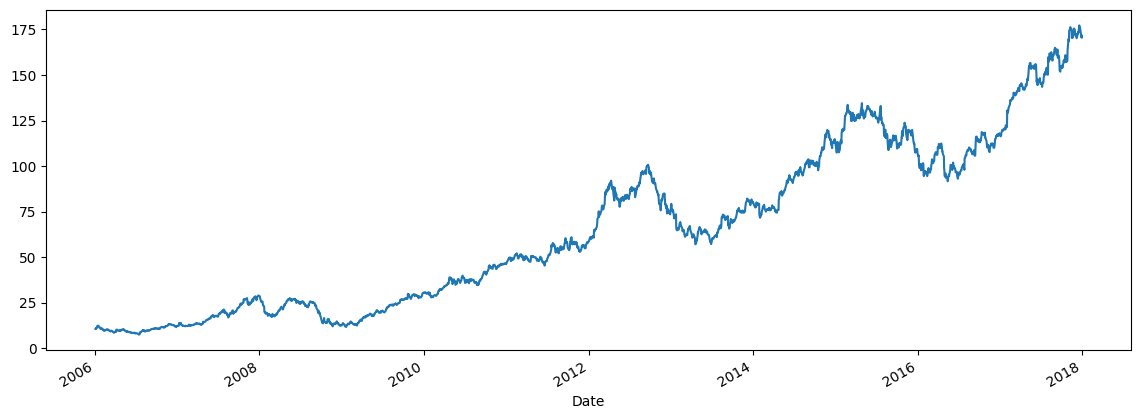

In [64]:
# plot all the high values
df['High'].plot(figsize=(14,5))
plt.show()

### 3.2 Visualize Training and Test Sets
Separating and plotting the 'High' price for the training set (before 2017) and the test set (since 2017) to see the split visually.

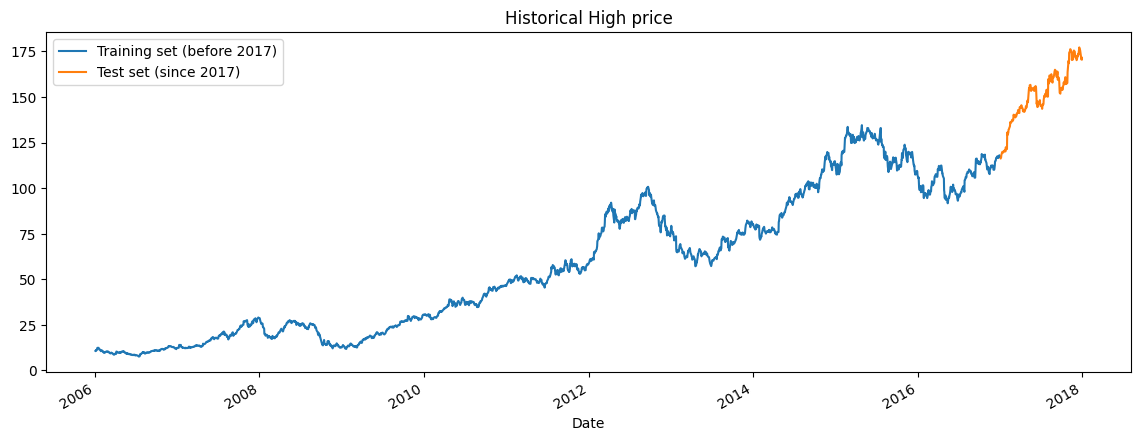

In [65]:
df['High'][:'2016'].plot(figsize=(14,5),legend=True)
df['High']['2017':].plot(figsize=(14,5),legend=True)
plt.legend(['Training set (before 2017)','Test set (since 2017)'])
plt.title('Historical High price')
plt.show()

##4. Splitting Data into Training and Test Sets
The 'High' column is extracted and split into training data (before 2017) and testing data (since 2017). The `.values` attribute converts the pandas Series to a NumPy array, and `iloc[:,1:2]` ensures it's a 2D array for consistent input shapes for the models.

In [66]:
# we will split the data into train and test
train = df[:'2016'].iloc[:,1:2].values
test = df['2017':].iloc[:,1:2].values

### 4.1 Checking Data Shapes
Displaying the shapes of the `train` and `test` arrays to confirm the split dimensions.

In [67]:
train.shape , test.shape

((2768, 1), (251, 1))

### 4.2 Initializing Variables for Time Series Preparation
Lists `x_train`, `y_train`, `x_test`, `y_test` are initialized. `timestamps` is set to 30, which defines the number of previous days' stock prices to consider for predicting the next day's price.

In [68]:
x_train = []
y_train = []
x_test = []
y_test = []

timestamps=30

### 4.3 Creating Training Sequences
This loop creates sequences for the training data. For each element `i` from `timestamps` to the end of the `train` set, `x_train` will contain the `timestamps` number of previous 'High' prices, and `y_train` will contain the 'High' price at index `i` (the target).

In [69]:
for i in range (timestamps,len(train)):
  x_train.append(train[i-timestamps:i,0])
  y_train.append(train[i,0])

### 4.4 Creating Test Sequences
Similar to the training sequences, this loop prepares the test data. For each element `i` from `timestamps` to the end of the `test` set, `x_test` will contain the `timestamps` number of previous 'High' prices from the `test` set, and `y_test` will contain the 'High' price at index `i` from the `test` set.

In [70]:
for i in range (timestamps,len(test)):
  x_test.append(train[i-timestamps:i,0])
  y_test.append(train[i,0])

### 4.5 Displaying Sample Training Examples
Showing the first 10 training examples, including the input sequence (`x_train`) and the corresponding target value (`y_train`).

In [71]:
for i in range(10):
  print("training Exaple: ",i+1)
  print(x_train[i], ":: ", y_train[i])

training Exaple:  1
[10.68 10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67
 11.43 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36
  9.93  9.87  9.89  9.67  9.54  9.73] ::  9.95
training Exaple:  2
[10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43
 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93
  9.87  9.89  9.67  9.54  9.73  9.95] ::  10.14
training Exaple:  3
[10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37
 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87
  9.89  9.67  9.54  9.73  9.95 10.14] ::  10.13
training Exaple:  4
[10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35
 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87  9.89
  9.67  9.54  9.73  9.95 10.14 10.13] ::  10.11
training Exaple:  5
[11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35 11.07
 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.

### 4.6 Displaying Sample Test Examples
Showing the first 10 test examples, including the input sequence (`x_test`) and the corresponding target value (`y_test`).

In [72]:
for i in range(10):
  print("Test Exaple: ",i+1)
  print(x_test[i], ":: ", y_test[i])


Test Exaple:  1
[10.68 10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67
 11.43 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36
  9.93  9.87  9.89  9.67  9.54  9.73] ::  9.95
Test Exaple:  2
[10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43
 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93
  9.87  9.89  9.67  9.54  9.73  9.95] ::  10.14
Test Exaple:  3
[10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37
 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87
  9.89  9.67  9.54  9.73  9.95 10.14] ::  10.13
Test Exaple:  4
[10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35
 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87  9.89
  9.67  9.54  9.73  9.95 10.14 10.13] ::  10.11
Test Exaple:  5
[11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35 11.07
 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87  9.89  9.67

### 4.7 Converting Lists to NumPy Arrays
Converting the `x_train`, `x_test`, `y_train`, and `y_test` lists into NumPy arrays, which are required for Keras models.

In [73]:
x_train=np.array(x_train)
x_test=np.array(x_test)
y_train=np.array(y_train)
y_test=np.array(y_test)

### 4.8 Reshaping Data for RNN Input
The `x_train` and `x_test` data are reshaped to a 3D format `(samples, timesteps, features)` which is required for SimpleRNN layers. For this univariate time series, `features` is 1.

In [93]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

## 5. Artificial Neural Network (ANN) Model
This section defines, compiles, and trains a simple Artificial Neural Network for stock price prediction.

In [74]:
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

### 5.1 Building the ANN Model
A sequential ANN model is created with one dense hidden layer and an output layer. The `input_dim` is set to `timestamps` as ANN expects a flattened input.

In [84]:
# Lets create a simple ANN model
model=Sequential()
model.add(Dense(units=16, activation='relu', input_dim=timestamps))
# model.add(Dense(units=32, activation='relu'))
# model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Compiling the ANN Model
The model is compiled using the 'adam' optimizer and 'mean_squared_error' as the loss function, with 'root_mean_squared_error' as a metric.

In [85]:
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['root_mean_squared_error'])

### 5.3 Training the ANN Model
The ANN model is trained on the `x_train` and `y_train` data for 10 epochs. Validation data (`x_test`, `y_test`) is used to monitor performance during training.

In [86]:
history=model.fit(x_train,y_train, epochs=10, validation_data=(x_test,y_test))

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 186.2475 - root_mean_squared_error: 13.6473 - val_loss: 0.8841 - val_root_mean_squared_error: 0.9402
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.0010 - root_mean_squared_error: 4.3590 - val_loss: 0.7973 - val_root_mean_squared_error: 0.8929
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.8237 - root_mean_squared_error: 4.2218 - val_loss: 0.7603 - val_root_mean_squared_error: 0.8720
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.2634 - root_mean_squared_error: 4.0328 - val_loss: 0.5856 - val_root_mean_squared_error: 0.7652
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.1787 - root_mean_squared_error: 3.6302 - val_loss: 0.5402 - val_root_mean_squared_error: 0.7350
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.8380 - root_mean_squared_error: 3.4406 - val_loss: 0.4991 - val_root_mean_squared_error: 0.7065
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

## 5. Recurrent Neural Network (RNN) Model
This section defines, compiles, and trains a simple Recurrent Neural Network for stock price prediction.

### 5.1 Building the RNN Model
A sequential RNN model using a SimpleRNN layer is created. The `input_shape` is `(timestamps, 1)` because RNNs expect 3D input `(batch_size, timesteps, features)`. A dense output layer is added.

In [87]:
# Lets create a simple RNN model
model_rnn=Sequential()
model_rnn.add(SimpleRNN(units=16,activation='relu', input_shape=(timestamps,1)))
# model_rnn.add(Dense(units=32, activation='relu'))
# model_rnn.add(Dense(units=64, activation='relu'))
model_rnn.add(Dense(units=1))
model_rnn.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Compiling the RNN Model
The RNN model is compiled using the 'adam' optimizer and 'mean_squared_error' as the loss function, with 'root_mean_squared_error' as a metric.

In [88]:
model_rnn.compile(optimizer='adam',
                  loss='mean_squared_error',
                  metrics=['root_mean_squared_error'])

### 5.3 Training the RNN Model
The RNN model is trained on the reshaped `x_train` and `y_train` data for 10 epochs, with validation data (`x_test`, `y_test`).

In [89]:
history_rnn=model_rnn.fit(x_train,y_train,
                          epochs=10,
                          validation_data=(x_test,y_test))

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2747.3345 - root_mean_squared_error: 52.4150 - val_loss: 0.8668 - val_root_mean_squared_error: 0.9310
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4044 - root_mean_squared_error: 2.3247 - val_loss: 0.1186 - val_root_mean_squared_error: 0.3444
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5956 - root_mean_squared_error: 1.2632 - val_loss: 0.1173 - val_root_mean_squared_error: 0.3424
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5909 - root_mean_squared_error: 1.2613 - val_loss: 0.1343 - val_root_mean_squared_error: 0.3665
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6008 - root_mean_squared_error: 1.2652 - val_loss: 0.1276 - val_root_mean_squared_error: 0.3572
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5969 - root_mean_squared_error: 1.2637 - val_loss: 0.1273 - val_root_mean_squared_error: 0.3568
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.

## 6. Prediction and Visualization
This section generates predictions from both trained models and visualizes them against the actual stock prices in the test set.

### 6.1 Generating Predictions with RNN Model
The trained RNN model `model_rnn` makes predictions on the `x_test` dataset.

In [90]:
y_pred=model_rnn.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


### 6.2 Generating Predictions with ANN Model
The trained ANN model `model` makes predictions on the `x_test` dataset.

In [91]:
y_pred_ann=model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


### 6.3 Visualizing Actual vs. Predicted Stock Prices
This plot compares the actual stock prices (`y_test`) with the predictions from both the RNN (`y_pred`) and ANN (`y_pred_ann`) models on the test set. This allows for a visual evaluation of each model's performance.

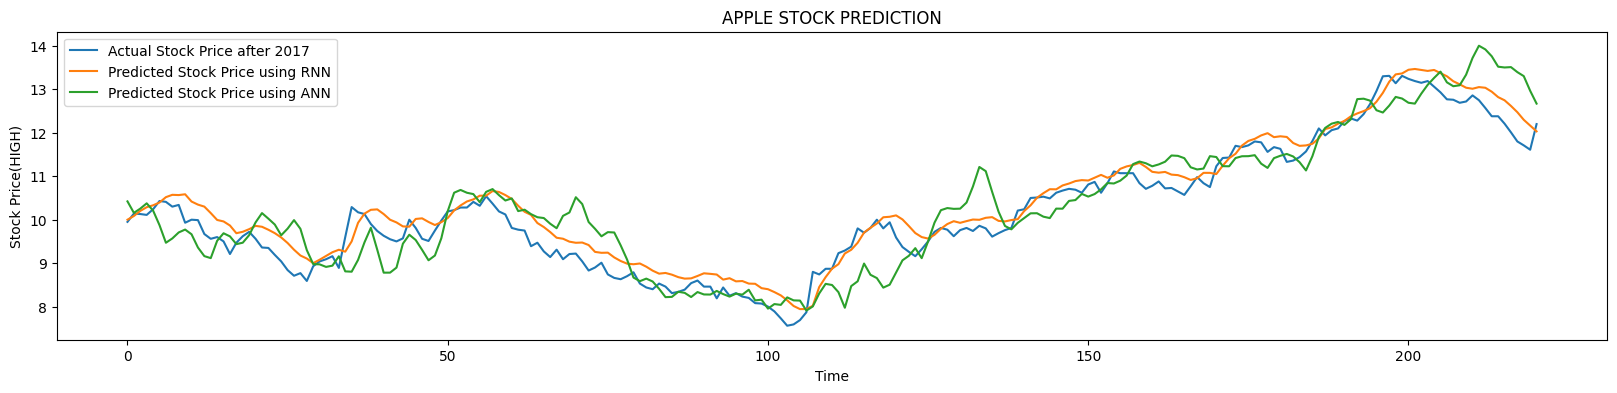

In [92]:
plt.figure(figsize=(20,4))
plt.plot(y_test,label="Actual Stock Price after 2017")
plt.plot(y_pred,label="Predicted Stock Price using RNN")
plt.plot(y_pred_ann,label="Predicted Stock Price using ANN")
plt.title("APPLE STOCK PREDICTION")
plt.xlabel("Time")
plt.ylabel("Stock Price(HIGH)")
plt.legend()
plt.show()